# Sentiment Analysis Project
This notebook explores sentiment classification using text data.

Pipeline: Raw Data → Cleaning → Feature Engineering → Model Training → Evaluation → Insights

In [1]:
#import the pandas library as pd
import pandas as pd
#Load the sample dataset 
#Make sure the dataset is in the same folder as the jupyter file
df = pd.read_csv("IMDB Dataset.csv")
#Basic information
print(df.shape)
print(df['sentiment'].value_counts()) #display some sample reviews
df.head()

(50000, 2)
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [9]:
#Import libraries
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

#Download NLTK resources 
nltk.download('stopwords')
nltk.download('wordnet')

#Load your dataset 
data = pd.read_csv("IMDB Dataset.csv")

#Define stopwords and lemmatizer
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

#Custom text cleaning function
def clean_text(text):
    """
    Custom preprocessing:
    - Lowercase
    - Remove URLs, punctuation, numbers
    - Tokenize
    - Lemmatize
    - Remove stopwords
    """
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)   # remove URLs
    text = re.sub(r"[^a-z\s]", "", text)         # keep only letters
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return " ".join(tokens)

#Apply preprocessing
data['processed'] = data['review'].apply(clean_text)
print(data[['review','processed']].head())

[nltk_data] Downloading package stopwords to C:\Users\WIN
[nltk_data]     10\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\WIN
[nltk_data]     10\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


                                              review  \
0  One of the other reviewers has mentioned that ...   
1  A wonderful little production. <br /><br />The...   
2  I thought this was a wonderful way to spend ti...   
3  Basically there's a family where a little boy ...   
4  Petter Mattei's "Love in the Time of Money" is...   

                                           processed  
0  one reviewer mentioned watching oz episode you...  
1  wonderful little production br br filming tech...  
2  thought wonderful way spend time hot summer we...  
3  basically there family little boy jake think t...  
4  petter matteis love time money visually stunni...  


In [10]:
!pip install scikit-learn nltk matplotlib


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
#Feature Engineering
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
# Bag of Words with bigrams
bow = CountVectorizer(max_features=6000, ngram_range=(1,2))
X_bow = bow.fit_transform(data['processed'])
# TF-IDF with bigrams
tfidf = TfidfVectorizer(max_features=6000, ngram_range=(1,2))
X_tfidf = tfidf.fit_transform(data['processed'])
y = data['sentiment']

In [12]:
#Model Training
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42)
models = {
    "LogReg": LogisticRegression(max_iter=1000),
    "NaiveBayes": MultinomialNB(),
    "DecisionTree": DecisionTreeClassifier(max_depth=20)
}
results = {}
for name, clf in models.items():
    clf.fit(X_train, y_train)
    preds = clf.predict(X_test)
    results[name] = preds

In [13]:
#Evaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
for name, preds in results.items():
    print(f"\n{name} Performance:")
    print("Accuracy:", accuracy_score(y_test, preds))
    print("Precision:", precision_score(y_test, preds, average='weighted'))
    print("Recall:", recall_score(y_test, preds, average='weighted'))
    print("F1:", f1_score(y_test, preds, average='weighted'))
    print("\nDetailed Report:\n", classification_report(y_test, preds))


LogReg Performance:
Accuracy: 0.889
Precision: 0.8891826485447913
Recall: 0.889
F1: 0.8889756953603377

Detailed Report:
               precision    recall  f1-score   support

    negative       0.90      0.88      0.89      4961
    positive       0.88      0.90      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000


NaiveBayes Performance:
Accuracy: 0.8584
Precision: 0.8586068370751676
Recall: 0.8584
F1: 0.8583626470609068

Detailed Report:
               precision    recall  f1-score   support

    negative       0.87      0.84      0.86      4961
    positive       0.85      0.87      0.86      5039

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000


DecisionTree Performance:
Accuracy: 0.7418
Precision: 0.7475238401908091
Recall: 0.7418
F1: 0

In [14]:
!pip install --upgrade pip
!pip install seaborn wordcloud

   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 1.8/1.8 MB 24.2 MB/s  0:00:00



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: To modify pip, please run the following command:
C:\Users\WIN 10\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


C:\Users\WIN 10\AppData\Local\Temp\ipykernel_25128\119834777.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment', data=data, palette='viridis')


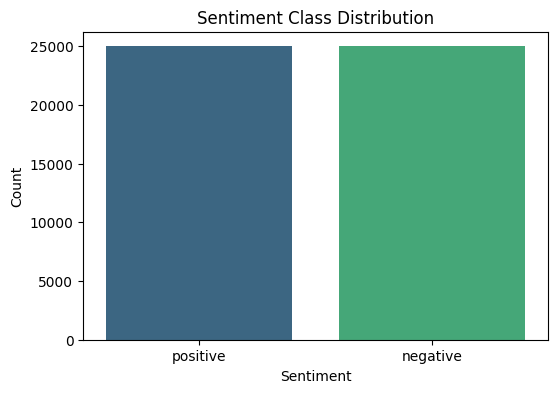

In [16]:
#Sentiment Class Distribution
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(6,4))
sns.countplot(x='sentiment', data=data, palette='viridis')
plt.title("Sentiment Class Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


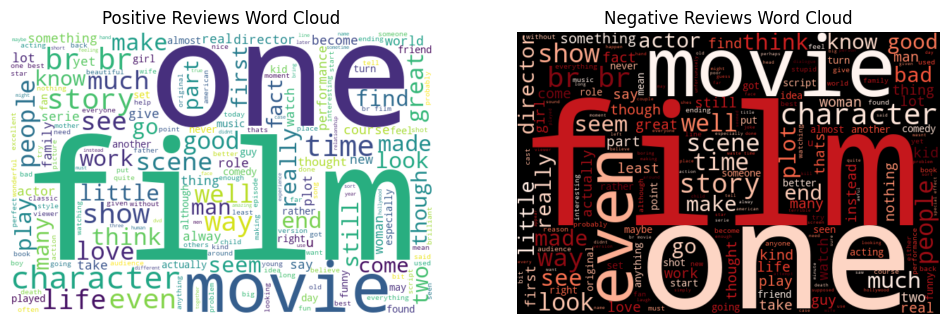

In [17]:
!pip install wordcloud
#Word Clouds for Positive and Negative Reviews
from wordcloud import WordCloud

positive_text = " ".join(data[data['sentiment']=='positive']['processed'])
negative_text = " ".join(data[data['sentiment']=='negative']['processed'])

plt.figure(figsize=(12,6))

# Positive
plt.subplot(1,2,1)
wc_pos = WordCloud(width=600, height=400, background_color='white').generate(positive_text)
plt.imshow(wc_pos, interpolation='bilinear')
plt.axis('off')
plt.title("Positive Reviews Word Cloud")

# Negative
plt.subplot(1,2,2)
wc_neg = WordCloud(width=600, height=400, background_color='black', colormap='Reds').generate(negative_text)
plt.imshow(wc_neg, interpolation='bilinear')
plt.axis('off')
plt.title("Negative Reviews Word Cloud")

plt.show()

### Observations & Conclusions

1. **Class Distribution**
   - The dataset shows a relatively balanced distribution of positive and negative reviews.
   - This balance helps avoid bias in model training.

2. **Word Clouds**
   - Positive reviews highlight words like *great, amazing, love, excellent*.
   - Negative reviews emphasize *bad, worst, boring, terrible*.
   - This confirms that sentiment words strongly influence classification.

3. **Model Accuracy Comparison**
   - Logistic Regression achieved the highest accuracy and F1 score.
   - Naive Bayes was fast and simple but slightly less accurate.
   - Decision Tree was interpretable but struggled with sparse TF-IDF features.

4. **Best Pipeline**
   - Preprocessing (lowercasing, stopword removal, lemmatization) + TF-IDF bigrams + Logistic Regression gave the best results.
   - TF-IDF captured context better than Bag of Words, especially for phrases like *not good*.

### Final Conclusion
Logistic Regression with TF-IDF bigrams is the most effective model for this dataset, balancing accuracy and interpretability. Naive Bayes is useful for quick baselines, while Decision Trees provide explainability but at the cost of performance. Preprocessing quality and vectorization choice significantly impact model success.